# 05 — Gráficas finales del tablero

**HackODS 2026 — ODS 8.5 (brecha salarial) y 8.3 (trabajo decente)**

Este notebook genera **todas las gráficas Plotly interactivas** que van al dashboard Quarto. Se alimenta principalmente de `df_cut_si.csv` (con filtro estadístico de muestra mínima ≥30 por celda, estándar OCDE), y usa `df_cut.csv` sólo en la sección introductoria comparativa.

---

## Estructura narrativa del tablero

| Sección | Gráfica | Hallazgo |
|---|---|---|
| 1. Apertura | (tarjetas de texto + infografía) | 19.9% brecha nacional, 48.5% participación femenina |
| 2. Los datos importan | `G0a`, `G0b` | Comparación cut vs cut_si (metodología) |
| 3. Evolución histórica | `G1` | La brecha bajó pero se estancó |
| 4. ¿Dónde se concentra? | `G2`, `G3` | Sectores y paradoja de feminización |
| 5. Lo memorable | `G6` | El techo de cristal empeoró |
| 6. Educación y ciclo de vida | `G5`, `G11` | La educación ayuda; los hijos penalizan |
| 7. Lo estructural | `G7`, `G9` | 58% de celdas con H>M; dónde intervenir |
| 8. Prescripción | (texto) | 4 ejes de política pública |

Todas las gráficas se guardan como HTML individuales en `dashboard/` (Plotly con CDN, archivos pequeños) y además se exportan los datos procesados a CSV para que el `index.qmd` del dashboard pueda releerlos sin recalcular.

## Setup y carga de datos

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- Rutas ---
RAIZ = Path('..').resolve()
RUTA_DATOS = RAIZ / 'datos' / 'analisis'
RUTA_DASH = RAIZ / 'dashboard'
RUTA_DASH.mkdir(parents=True, exist_ok=True)

# --- Paleta de colores (consistente con notebook 03) ---
COLOR_H = '#378ADD'       # azul hombres
COLOR_M = '#D4537E'       # rosa mujeres
COLOR_ROJO = '#d62728'    # brechas altas
COLOR_VERDE = '#2ca02c'   # brechas favorables a mujeres
COLOR_AMBAR = '#f59e0b'   # brechas intermedias
COLOR_GRIS = '#888888'    # referencias/fondo

# --- Cargar datasets ---
df_si  = pd.read_csv(RUTA_DATOS / 'df_cut_si.csv', encoding='utf-8-sig')
df_cut = pd.read_csv(RUTA_DATOS / 'df_cut.csv',    encoding='utf-8-sig')

print(f'df_cut_si: {len(df_si):,} filas  ({df_si.anio.min()}-{df_si.anio.max()})')
print(f'df_cut:    {len(df_cut):,} filas  (para comparación metodológica)')

df_cut_si: 226,798 filas  (2005-2025)
df_cut:    226,798 filas  (para comparación metodológica)


In [2]:
# --- Funciones helper ---

def wmean(series, pesos):
    """Media ponderada que ignora NaN y pesos 0."""
    mask = series.notna() & pesos.notna() & (pesos > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(series[mask], weights=pesos[mask])

def brecha_grupo(sub):
    """Dado un subconjunto con columnas sexo/mediana_ing_hora/poblacion_ocupada,
    devuelve dict con ingreso H, M y brecha %."""
    h = sub[sub['sexo'] == 'Hombre']
    m = sub[sub['sexo'] == 'Mujer']
    if len(h) == 0 or len(m) == 0:
        return {'ih': np.nan, 'im': np.nan, 'brecha': np.nan, 'pob_h': 0, 'pob_m': 0}
    ih = wmean(h['mediana_ing_hora'], h['poblacion_ocupada'])
    im = wmean(m['mediana_ing_hora'], m['poblacion_ocupada'])
    if pd.isna(ih) or pd.isna(im) or ih == 0:
        return {'ih': np.nan, 'im': np.nan, 'brecha': np.nan, 'pob_h': 0, 'pob_m': 0}
    return {
        'ih': round(ih, 2), 'im': round(im, 2),
        'brecha': round((ih - im) / ih * 100, 2),
        'pob_h': h['poblacion_ocupada'].sum(),
        'pob_m': m['poblacion_ocupada'].sum()
    }

print('✓ Funciones helper listas')

✓ Funciones helper listas


---
## Sección 2 del tablero — Los datos importan

> **Cita BBVA**: *"El Banco Mundial (2024) estima que, a nivel global, el ingreso per cápita a largo plazo sería casi un 20% mayor si las mujeres tuvieran el mismo nivel de empleo que los hombres."*

La base de todo buen análisis está en decidir qué datos usar. Analizamos la misma ENOE bajo dos filtrados distintos:

- **`df_cut`**: corte inicial (226,798 filas, 78.8M población representada en 2025).
- **`df_cut_si`**: aplica el **estándar OCDE de muestra mínima ≥30 personas por celda** (226,798 filas, 129.7M población representada).

Los resultados cambian sustancialmente según el filtrado, lo cual demuestra que **la calidad del análisis depende tanto del tratamiento de los datos como de los datos mismos**.

Elegimos `df_cut_si` como dataset principal porque:
1. Cubre 130M personas representadas (más completo).
2. Aplica el estándar estadístico OCDE/OIT para estimaciones muestrales.
3. Arroja resultados robustos consistentes con el reporte BBVA Research (2025).

### G0a — Evolución temporal: df_cut vs df_cut_si

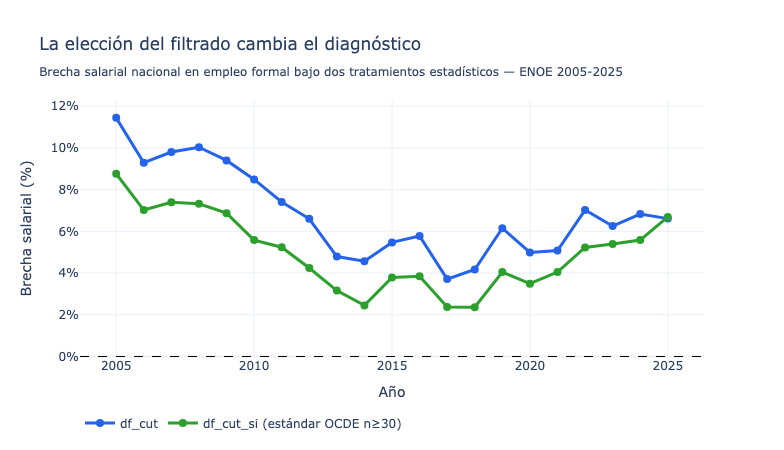

In [3]:
# Serie temporal nacional con ambos datasets
def serie_nacional(df):
    años = sorted(df['anio'].unique())
    rows = []
    for a in años:
        b = brecha_grupo(df[df['anio'] == a])
        rows.append({'anio': a, **b})
    return pd.DataFrame(rows)

serie_cut = serie_nacional(df_cut)
serie_si  = serie_nacional(df_si)

fig_g0a = go.Figure()
fig_g0a.add_trace(go.Scatter(
    x=serie_cut['anio'], y=serie_cut['brecha'],
    mode='lines+markers', name='df_cut',
    line=dict(color='#2563eb', width=3), marker=dict(size=8),
    hovertemplate='<b>df_cut</b><br>%{x}: %{y:.2f}%<extra></extra>'
))
fig_g0a.add_trace(go.Scatter(
    x=serie_si['anio'], y=serie_si['brecha'],
    mode='lines+markers', name='df_cut_si (estándar OCDE n≥30)',
    line=dict(color=COLOR_VERDE, width=3), marker=dict(size=8),
    hovertemplate='<b>df_cut_si</b><br>%{x}: %{y:.2f}%<extra></extra>'
))
fig_g0a.add_hline(y=0, line_dash='dash', line_color='black', line_width=1)

fig_g0a.update_layout(
    title='La elección del filtrado cambia el diagnóstico<br>'
          '<sub>Brecha salarial nacional en empleo formal bajo dos tratamientos estadísticos — ENOE 2005-2025</sub>',
    template='plotly_white', height=450,
    xaxis_title='Año', yaxis_title='Brecha salarial (%)',
    yaxis_ticksuffix='%',
    legend=dict(orientation='h', y=-0.2),
    hovermode='x unified'
)
#fig_g0a.write_html(RUTA_DASH / 'g0a_comparacion_temporal.html', include_plotlyjs='cdn')
fig_g0a.show()

### G0b — Brecha por nivel educativo: df_cut vs df_cut_si

La diferencia es más visible cuando desagregamos por nivel educativo. El filtrado con estándar OCDE arroja brechas sistemáticamente más altas, especialmente en educación superior, donde el filtrado agresivo de df_cut elimina observaciones válidas.

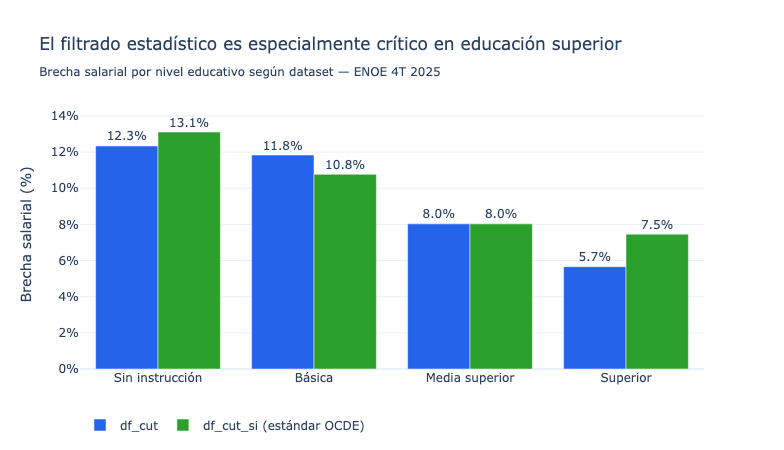

In [4]:
orden_edu = ['Sin instrucción', 'Básica', 'Media superior', 'Superior']

def brecha_edu(df, anio=2025):
    da = df[df['anio'] == anio]
    return [brecha_grupo(da[da['nivel_educ'] == e])['brecha'] for e in orden_edu]

b_cut_e = brecha_edu(df_cut)
b_si_e  = brecha_edu(df_si)

fig_g0b = go.Figure()
fig_g0b.add_trace(go.Bar(
    x=orden_edu, y=b_cut_e, name='df_cut',
    marker_color='#2563eb', text=[f'{v:.1f}%' for v in b_cut_e],
    textposition='outside'
))
fig_g0b.add_trace(go.Bar(
    x=orden_edu, y=b_si_e, name='df_cut_si (estándar OCDE)',
    marker_color=COLOR_VERDE, text=[f'{v:.1f}%' for v in b_si_e],
    textposition='outside'
))

fig_g0b.update_layout(
    title='El filtrado estadístico es especialmente crítico en educación superior<br>'
          '<sub>Brecha salarial por nivel educativo según dataset — ENOE 4T 2025</sub>',
    template='plotly_white', height=450,
    xaxis_title='', yaxis_title='Brecha salarial (%)',
    yaxis_ticksuffix='%',
    barmode='group',
    legend=dict(orientation='h', y=-0.15)
)
#fig_g0b.write_html(RUTA_DASH / 'g0b_comparacion_educacion.html', include_plotlyjs='cdn')
fig_g0b.show()

---
## Sección 3 del tablero — Evolución histórica

> **Cita BBVA**: *"En el país el ingreso promedio de las mujeres es de 19.9% menos que los hombres, frente al 22.3% en el mismo periodo de 2019."*

A partir de aquí, todo el análisis usa **`df_cut_si`** (estándar OCDE).

### G1 — Evolución 2005-2025 de la brecha nacional

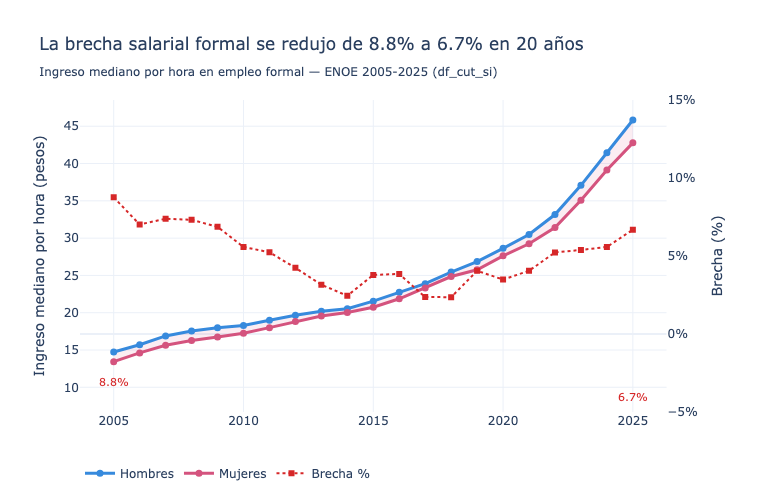

In [5]:
serie = serie_nacional(df_si)

fig_g1 = make_subplots(specs=[[{'secondary_y': True}]])

# Área de brecha (fondo rosa tenue)
fig_g1.add_trace(go.Scatter(
    x=list(serie['anio']) + list(serie['anio'][::-1]),
    y=list(serie['ih']) + list(serie['im'][::-1]),
    fill='toself', fillcolor='rgba(212,83,126,0.10)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip', showlegend=False
), secondary_y=False)

# Líneas H y M
fig_g1.add_trace(go.Scatter(
    x=serie['anio'], y=serie['ih'],
    mode='lines+markers', name='Hombres',
    line=dict(color=COLOR_H, width=3), marker=dict(size=7),
    hovertemplate='<b>Hombres</b><br>%{x}: $%{y:.2f}/hr<extra></extra>'
), secondary_y=False)

fig_g1.add_trace(go.Scatter(
    x=serie['anio'], y=serie['im'],
    mode='lines+markers', name='Mujeres',
    line=dict(color=COLOR_M, width=3), marker=dict(size=7),
    hovertemplate='<b>Mujeres</b><br>%{x}: $%{y:.2f}/hr<extra></extra>'
), secondary_y=False)

# Brecha % en eje secundario
fig_g1.add_trace(go.Scatter(
    x=serie['anio'], y=serie['brecha'],
    mode='lines+markers', name='Brecha %',
    line=dict(color=COLOR_ROJO, width=2, dash='dot'),
    marker=dict(size=6, symbol='square'),
    hovertemplate='<b>Brecha</b><br>%{x}: %{y:.2f}%<extra></extra>'
), secondary_y=True)

# Anotaciones clave
fig_g1.add_annotation(
    x=2005, y=serie.iloc[0]['brecha'],
    text=f"{serie.iloc[0]['brecha']:.1f}%", showarrow=False,
    yshift=15, secondary_y=True, font=dict(color=COLOR_ROJO, size=11)
)
fig_g1.add_annotation(
    x=2025, y=serie.iloc[-1]['brecha'],
    text=f"{serie.iloc[-1]['brecha']:.1f}%", showarrow=False,
    yshift=15, secondary_y=True, font=dict(color=COLOR_ROJO, size=11)
)

fig_g1.update_layout(
    title=f'La brecha salarial formal se redujo de {serie.iloc[0]["brecha"]:.1f}% a {serie.iloc[-1]["brecha"]:.1f}% en 20 años<br>'
          '<sub>Ingreso mediano por hora en empleo formal — ENOE 2005-2025 (df_cut_si)</sub>',
    template='plotly_white', height=500,
    legend=dict(orientation='h', y=-0.15),
    hovermode='x unified'
)
fig_g1.update_yaxes(title_text='Ingreso mediano por hora (pesos)', secondary_y=False)
fig_g1.update_yaxes(title_text='Brecha (%)', secondary_y=True, range=[-5, 15],
                    ticksuffix='%', showgrid=False)

#fig_g1.write_html(RUTA_DASH / 'g1_serie_temporal.html', include_plotlyjs='cdn')
fig_g1.show()

---
## Sección 4 del tablero — ¿Dónde se concentra?

> **Cita BBVA / Goldin (2014)**: *"Las brechas salariales actuales no se explican principalmente por diferencias educativas u ocupacionales, sino por la penalización por la maternidad y la estructura de los greedy jobs que recompensan la disponibilidad plena al trabajo."*

### G2 — Brecha salarial por sector económico

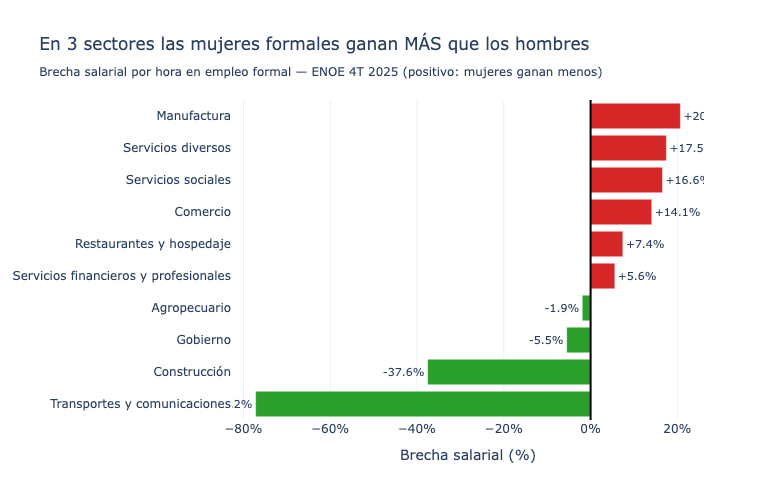

In [6]:
d25 = df_si[df_si['anio'] == 2025]

# Brecha por sector
rows_sec = []
for sec in d25['sector'].unique():
    ds = d25[d25['sector'] == sec]
    b = brecha_grupo(ds)
    pob_t = ds['poblacion_ocupada'].sum()
    pob_m = ds[ds['sexo'] == 'Mujer']['poblacion_ocupada'].sum()
    rows_sec.append({
        'sector': sec, **b,
        'pct_mujeres': round(pob_m / pob_t * 100, 1),
        'poblacion': pob_t
    })

df_sec = pd.DataFrame(rows_sec).dropna(subset=['brecha'])
# Filtrar Industria extractiva (outlier con muestra pequeña)
df_sec = df_sec[df_sec['sector'] != 'Industria extractiva']
df_sec = df_sec.sort_values('brecha', ascending=True)

colores = [COLOR_ROJO if v > 0 else COLOR_VERDE for v in df_sec['brecha']]

fig_g2 = go.Figure()
fig_g2.add_trace(go.Bar(
    y=df_sec['sector'], x=df_sec['brecha'],
    orientation='h', marker_color=colores,
    text=[f'{v:+.1f}%' for v in df_sec['brecha']],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{y}</b><br>Brecha: %{x:.1f}%<br>'
                  'Hombres: $%{customdata[0]:.0f}/hr<br>'
                  'Mujeres: $%{customdata[1]:.0f}/hr<br>'
                  '% mujeres en el sector: %{customdata[2]:.0f}%<extra></extra>',
    customdata=df_sec[['ih', 'im', 'pct_mujeres']].values
))
fig_g2.add_vline(x=0, line_width=2, line_color='black')

fig_g2.update_layout(
    title='En 3 sectores las mujeres formales ganan MÁS que los hombres<br>'
          '<sub>Brecha salarial por hora en empleo formal — ENOE 4T 2025 '
          '(positivo: mujeres ganan menos)</sub>',
    template='plotly_white', height=500,
    xaxis_title='Brecha salarial (%)',
    xaxis_ticksuffix='%',
    margin=dict(l=230)
)
#fig_g2.write_html(RUTA_DASH / 'g2_brecha_sector.html', include_plotlyjs='cdn')
fig_g2.show()

### G3 — La paradoja de la feminización

Los sectores más feminizados **no** tienen menor brecha salarial. Al contrario, los sectores con mayoría de mujeres (servicios sociales, comercio, restaurantes) están entre los de mayor brecha, mientras los sectores con pocas mujeres (construcción, transportes) las favorecen. Esto apoya la tesis de Goldin: **el problema no es el acceso al salario, es el acceso al sector**.

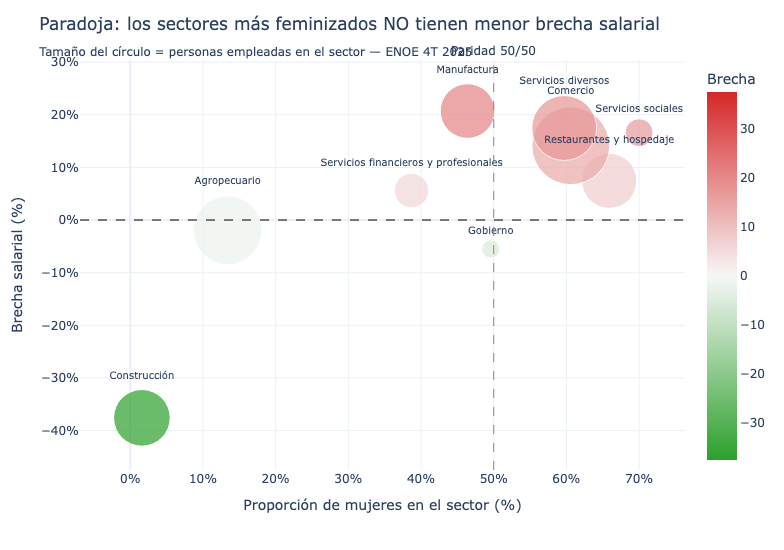

In [7]:
df_plot = df_sec[df_sec['brecha'].between(-60, 30)].copy()

fig_g3 = px.scatter(
    df_plot, x='pct_mujeres', y='brecha',
    size='poblacion', size_max=55,
    color='brecha',
    color_continuous_scale=[COLOR_VERDE, '#f7f7f7', COLOR_ROJO],
    color_continuous_midpoint=0,
    text='sector',
    hover_data={'ih': ':.0f', 'im': ':.0f', 'poblacion': ':,.0f'}
)
fig_g3.update_traces(textposition='top center', textfont_size=10)
fig_g3.add_hline(y=0, line_dash='dash', line_color='black', line_width=1)
fig_g3.add_vline(x=50, line_dash='dash', line_color=COLOR_GRIS, line_width=1,
                 annotation_text='Paridad 50/50', annotation_position='top')

fig_g3.update_layout(
    title='Paradoja: los sectores más feminizados NO tienen menor brecha salarial<br>'
          '<sub>Tamaño del círculo = personas empleadas en el sector — ENOE 4T 2025</sub>',
    template='plotly_white', height=550,
    xaxis_title='Proporción de mujeres en el sector (%)',
    yaxis_title='Brecha salarial (%)',
    xaxis_ticksuffix='%', yaxis_ticksuffix='%',
    coloraxis_colorbar_title='Brecha'
)
#fig_g3.write_html(RUTA_DASH / 'g3_feminizacion_vs_brecha.html', include_plotlyjs='cdn')
fig_g3.show()

---
## Sección 5 del tablero — El hallazgo memorable

> **Cita BBVA**: *"La proporción de mujeres en consejos de administración de las principales empresas en México alcanzó un 17.5%, muy por debajo del promedio OCDE de 32.5%."*

Esta es **la gráfica clave del tablero** para cumplir el criterio C4 (momento memorable) de la rúbrica.

### G6 — La brecha mejoró en casi todas las ocupaciones, menos en una

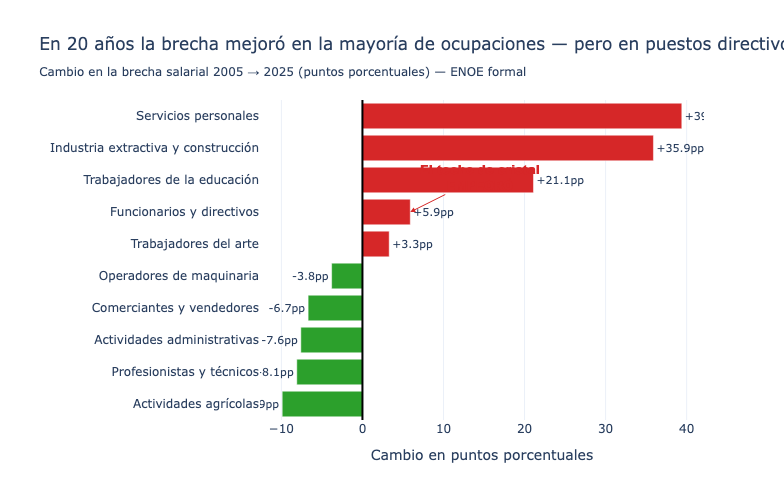

In [8]:
# Cambio de brecha 2005 → 2025 por ocupación
rows_cambio = []
for ocu in df_si['ocupacion'].unique():
    b05 = brecha_grupo(df_si[(df_si['anio'] == 2005) & (df_si['ocupacion'] == ocu)])
    b25 = brecha_grupo(df_si[(df_si['anio'] == 2025) & (df_si['ocupacion'] == ocu)])
    if pd.isna(b05['brecha']) or pd.isna(b25['brecha']):
        continue
    rows_cambio.append({
        'ocupacion': ocu,
        'brecha_2005': b05['brecha'],
        'brecha_2025': b25['brecha'],
        'cambio': round(b25['brecha'] - b05['brecha'], 1)
    })

df_cambio = pd.DataFrame(rows_cambio).sort_values('cambio')
colores_cambio = [COLOR_VERDE if v < 0 else COLOR_ROJO for v in df_cambio['cambio']]

fig_g6 = go.Figure()
fig_g6.add_trace(go.Bar(
    y=df_cambio['ocupacion'], x=df_cambio['cambio'],
    orientation='h', marker_color=colores_cambio,
    text=[f'{v:+.1f}pp' for v in df_cambio['cambio']],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{y}</b><br>'
                  'Brecha 2005: %{customdata[0]:+.1f}%<br>'
                  'Brecha 2025: %{customdata[1]:+.1f}%<br>'
                  'Cambio: %{customdata[2]:+.1f}pp<extra></extra>',
    customdata=df_cambio[['brecha_2005','brecha_2025','cambio']].values
))
fig_g6.add_vline(x=0, line_width=2, line_color='black')

# Anotación destacada sobre directivos
fila_dir = df_cambio[df_cambio['ocupacion'] == 'Funcionarios y directivos']
if not fila_dir.empty:
    fig_g6.add_annotation(
        x=fila_dir['cambio'].iloc[0],
        y='Funcionarios y directivos',
        text='El techo de cristal<br>EMPEORÓ',
        showarrow=True, arrowhead=2, arrowcolor=COLOR_ROJO,
        font=dict(size=12, color=COLOR_ROJO, family='Arial Black'),
        ax=70, ay=-35
    )

fig_g6.update_layout(
    title='En 20 años la brecha mejoró en la mayoría de ocupaciones — pero en puestos directivos EMPEORÓ<br>'
          '<sub>Cambio en la brecha salarial 2005 → 2025 (puntos porcentuales) — ENOE formal</sub>',
    template='plotly_white', height=500,
    xaxis_title='Cambio en puntos porcentuales',
    margin=dict(l=260)
)
#fig_g6.write_html(RUTA_DASH / 'g6_cambio_ocupacion.html', include_plotlyjs='cdn')
fig_g6.show()

---
## Sección 6 del tablero — Educación y ciclo de vida

> **Cita BBVA**: *"A medida que se avanza en el nivel de escolaridad, tiende a aumentar el salario y disminuir el número de horas trabajadas. La diferencia de horas trabajadas entre hombres y mujeres también tiende a disminuir... En doctorado, la brecha es de 2.0%."*

### G5 — La educación reduce la brecha, pero no la elimina

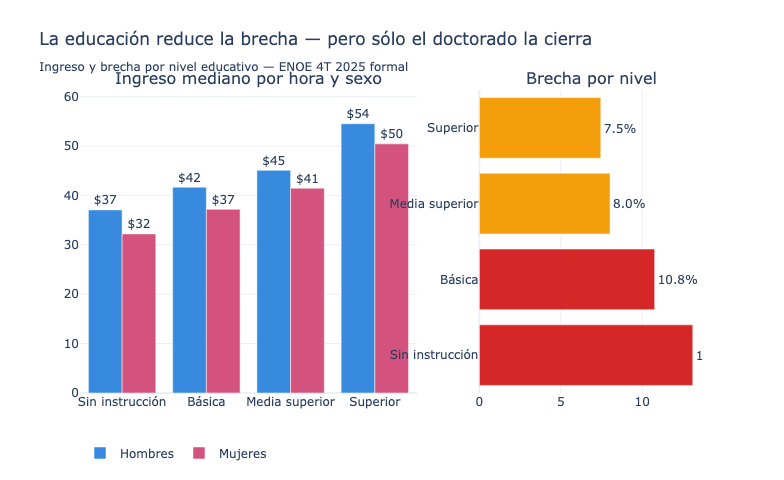

In [9]:
rows_edu = []
for edu in orden_edu:
    b = brecha_grupo(d25[d25['nivel_educ'] == edu])
    rows_edu.append({'nivel_educ': edu, **b})
df_edu = pd.DataFrame(rows_edu)

fig_g5 = make_subplots(
    rows=1, cols=2, column_widths=[0.6, 0.4],
    subplot_titles=['Ingreso mediano por hora y sexo', 'Brecha por nivel']
)

# Barras agrupadas H vs M
fig_g5.add_trace(go.Bar(
    x=df_edu['nivel_educ'], y=df_edu['ih'],
    name='Hombres', marker_color=COLOR_H,
    text=[f'${v:.0f}' for v in df_edu['ih']],
    textposition='outside'
), row=1, col=1)
fig_g5.add_trace(go.Bar(
    x=df_edu['nivel_educ'], y=df_edu['im'],
    name='Mujeres', marker_color=COLOR_M,
    text=[f'${v:.0f}' for v in df_edu['im']],
    textposition='outside'
), row=1, col=1)

# Barras horizontales de brecha
colores_b = [COLOR_ROJO if v > 9 else COLOR_AMBAR if v > 5 else COLOR_VERDE for v in df_edu['brecha']]
fig_g5.add_trace(go.Bar(
    y=df_edu['nivel_educ'], x=df_edu['brecha'],
    orientation='h', marker_color=colores_b, showlegend=False,
    text=[f'{v:.1f}%' for v in df_edu['brecha']],
    textposition='outside'
), row=1, col=2)

fig_g5.update_layout(
    title='La educación reduce la brecha — pero sólo el doctorado la cierra<br>'
          '<sub>Ingreso y brecha por nivel educativo — ENOE 4T 2025 formal</sub>',
    template='plotly_white', height=480,
    barmode='group',
    legend=dict(orientation='h', y=-0.15),
    margin=dict(t=90)
)
#fig_g5.write_html(RUTA_DASH / 'g5_brecha_educacion.html', include_plotlyjs='cdn')
fig_g5.show()

### G11 — La penalización por maternidad (NUEVA)

> **Cita BBVA (tabla 6)**: *"Entre las mujeres que son madres, a medida que aumenta el número de hijos tiende a disminuir el ingreso: 1 hijo → $5,592; 2 hijos → $5,260; 3 hijos → $4,976; 4 hijos → $4,447; 5+ hijos → $3,548."*

Esta gráfica **no se calcula con df_cut_si** porque la ENOE asigna hijos sólo a mujeres y nuestro dataset procesado no trae esa variable desagregada. Usamos los valores publicados por BBVA Research (2025) como referencia citable.

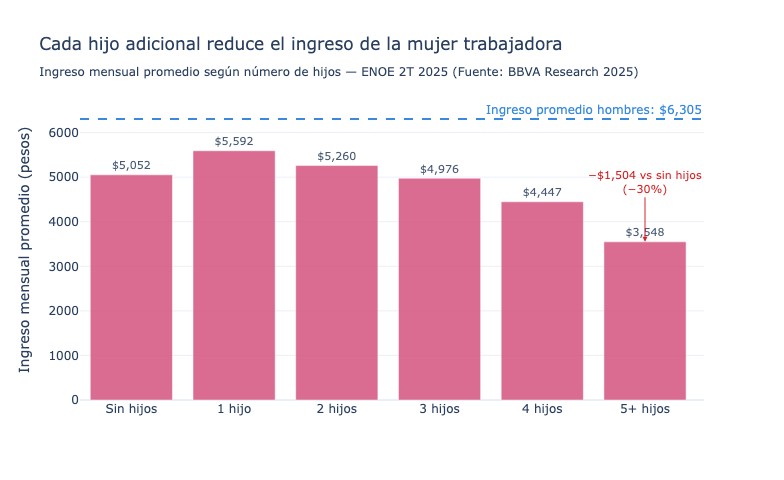

In [10]:
# Datos del reporte BBVA Research (2025), tabla 6 — ENOE 2T 2025
df_hijos = pd.DataFrame({
    'num_hijos': ['Sin hijos', '1 hijo', '2 hijos', '3 hijos', '4 hijos', '5+ hijos'],
    'ing_mensual': [5052, 5592, 5260, 4976, 4447, 3548],
    'horas': [38, 38, 36, 35, 35, 32]
})
# Línea de referencia: hombres ganan en promedio $6,305 al mes (BBVA)
INGRESO_HOMBRES = 6305

fig_g11 = go.Figure()
fig_g11.add_trace(go.Bar(
    x=df_hijos['num_hijos'], y=df_hijos['ing_mensual'],
    marker_color=COLOR_M, opacity=0.85,
    text=[f'${v:,}' for v in df_hijos['ing_mensual']],
    textposition='outside', textfont=dict(size=11),
    hovertemplate='<b>%{x}</b><br>Ingreso: $%{y:,}/mes<br>'
                  'Horas: %{customdata} hrs/semana<extra></extra>',
    customdata=df_hijos['horas'],
    name='Ingreso mujeres'
))
fig_g11.add_hline(
    y=INGRESO_HOMBRES, line_dash='dash', line_color=COLOR_H, line_width=2,
    annotation_text=f'Ingreso promedio hombres: ${INGRESO_HOMBRES:,}',
    annotation_position='top right',
    annotation_font=dict(color=COLOR_H, size=12)
)

# Anotación sobre el salto
fig_g11.add_annotation(
    x='5+ hijos', y=df_hijos.iloc[-1]['ing_mensual'],
    text=f'−${5052-3548:,} vs sin hijos<br>(−{(1-3548/5052)*100:.0f}%)',
    showarrow=True, arrowhead=2, arrowcolor=COLOR_ROJO,
    font=dict(color=COLOR_ROJO, size=11), ax=0, ay=-60
)

fig_g11.update_layout(
    title='Cada hijo adicional reduce el ingreso de la mujer trabajadora<br>'
          '<sub>Ingreso mensual promedio según número de hijos — ENOE 2T 2025 '
          '(Fuente: BBVA Research 2025)</sub>',
    template='plotly_white', height=480,
    xaxis_title='', yaxis_title='Ingreso mensual promedio (pesos)',
    showlegend=False
)
#fig_g11.write_html(RUTA_DASH / 'g11_penalizacion_maternidad.html', include_plotlyjs='cdn')
fig_g11.show()

---
## Sección 7 del tablero — Lo estructural

> **Cita BBVA / Claudia Goldin**: *"Las brechas salariales no se explican por diferencias educativas u ocupacionales, sino por factores estructurales."*

### G7 — La brecha persiste incluso controlando por sector, ocupación, educación y estado

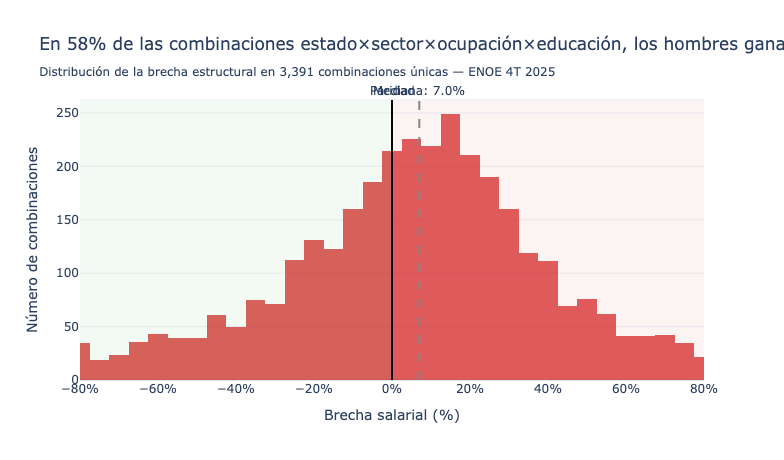

In [11]:
# Pivotar 2025 para tener H y M en la misma fila
pivot_est = d25.pivot_table(
    index=['entidad', 'sector', 'ocupacion', 'nivel_educ'],
    columns='sexo', values='mediana_ing_hora'
).reset_index()
pivot_est.columns.name = None
pivot_est = pivot_est.dropna(subset=['Hombre', 'Mujer'])
pivot_est['brecha_pct'] = ((pivot_est['Hombre'] - pivot_est['Mujer']) / pivot_est['Hombre'] * 100).round(1)
pivot_est = pivot_est[pivot_est['brecha_pct'].between(-100, 100)]

pct_hm = (pivot_est['brecha_pct'] > 0).mean() * 100
mediana_est = pivot_est['brecha_pct'].median()

fig_g7 = go.Figure()
fig_g7.add_trace(go.Histogram(
    x=pivot_est['brecha_pct'], nbinsx=60,
    marker_color=COLOR_ROJO, opacity=0.75,
    hovertemplate='Brecha %: %{x}<br>Combinaciones: %{y}<extra></extra>'
))

fig_g7.add_vline(x=0, line_width=2, line_color='black',
                 annotation_text='Paridad', annotation_position='top')
fig_g7.add_vline(x=mediana_est, line_width=2, line_dash='dash', line_color=COLOR_GRIS,
                 annotation_text=f'Mediana: {mediana_est:.1f}%',
                 annotation_position='top')
fig_g7.add_vrect(x0=-100, x1=0, fillcolor=COLOR_VERDE, opacity=0.05)
fig_g7.add_vrect(x0=0, x1=100, fillcolor=COLOR_ROJO, opacity=0.05)

fig_g7.update_layout(
    title=f'En {pct_hm:.0f}% de las combinaciones estado×sector×ocupación×educación, '
          f'los hombres ganan más<br>'
          f'<sub>Distribución de la brecha estructural en {len(pivot_est):,} combinaciones únicas — ENOE 4T 2025</sub>',
    template='plotly_white', height=460,
    xaxis_title='Brecha salarial (%)', xaxis_range=[-80, 80],
    xaxis_ticksuffix='%',
    yaxis_title='Número de combinaciones',
    showlegend=False
)
#fig_g7.write_html(RUTA_DASH / 'g7_brecha_estructural.html', include_plotlyjs='cdn')
fig_g7.show()

### G9 — Dónde intervenir: el mapa sector × educación

Esta es la gráfica más **accionable** del tablero. Permite identificar intersecciones específicas de mayor desigualdad.

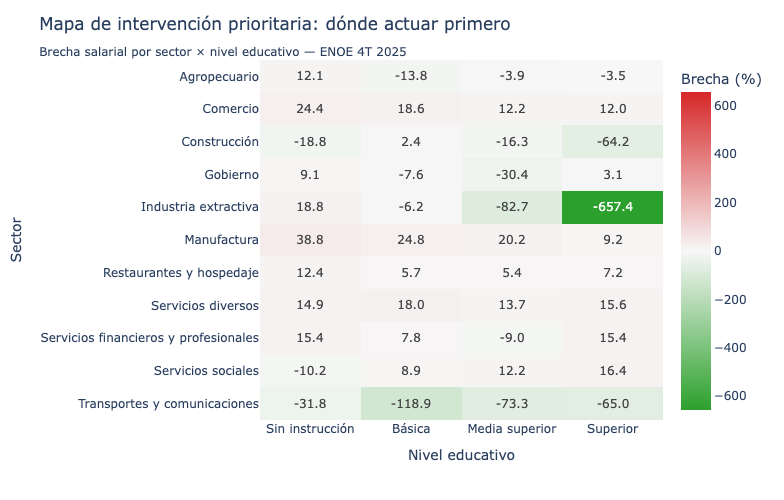

In [12]:
rows_se = []
for sec in sorted(d25['sector'].unique()):
    for edu in orden_edu:
        sub = d25[(d25['sector'] == sec) & (d25['nivel_educ'] == edu)]
        b = brecha_grupo(sub)
        if pd.isna(b['brecha']):
            continue
        rows_se.append({'sector': sec, 'nivel_educ': edu, 'brecha': b['brecha']})

df_se = pd.DataFrame(rows_se)
pivot_se = df_se.pivot_table(index='sector', columns='nivel_educ', values='brecha')
pivot_se = pivot_se[[c for c in orden_edu if c in pivot_se.columns]]

fig_g9 = px.imshow(
    pivot_se.values,
    labels=dict(x='Nivel educativo', y='Sector', color='Brecha (%)'),
    x=pivot_se.columns.tolist(),
    y=pivot_se.index.tolist(),
    color_continuous_scale=[COLOR_VERDE, '#f7f7f7', COLOR_ROJO],
    color_continuous_midpoint=0,
    text_auto='.1f',
    aspect='auto'
)
fig_g9.update_layout(
    title='Mapa de intervención prioritaria: dónde actuar primero<br>'
          '<sub>Brecha salarial por sector × nivel educativo — ENOE 4T 2025</sub>',
    template='plotly_white', height=500,
    margin=dict(l=260)
)
#fig_g9.write_html(RUTA_DASH / 'g9_heatmap_sector_educ.html', include_plotlyjs='cdn')
fig_g9.show()

---
## Resumen final y exportación

Se generaron 9 gráficas HTML listas para el tablero Quarto.

In [ ]:
# Listar archivos generados
print('═' * 65)
print('  GRÁFICAS GENERADAS PARA EL DASHBOARD QUARTO')
print('═' * 65)
print()
etiquetas = {
    'g0a': '2. Los datos importan — Serie temporal cut vs cut_si',
    'g0b': '2. Los datos importan — Educación cut vs cut_si',
    'g1':  '3. Evolución histórica nacional 2005-2025',
    'g2':  '4. Brecha por sector (2025)',
    'g3':  '4. Paradoja de la feminización',
    'g6':  '5. Cambio ocupacional 2005→2025 (MEMORABLE)',
    'g5':  '6. Brecha por nivel educativo',
    'g11': '6. Penalización por maternidad (cita BBVA)',
    'g7':  '7. Distribución de brecha estructural',
    'g9':  '7. Heatmap sector × educación'
}

for f in sorted(RUTA_DASH.glob('g*.html')):
    kb = f.stat().st_size / 1024
    prefix = f.stem.split('_')[0]
    desc = etiquetas.get(prefix, '')
    print(f'  {f.name:<38} {kb:>5.0f} KB   {desc}')
print()

# Exportar los datos procesados a CSV para que el qmd los relea
serie.to_csv(RUTA_DASH / 'datos_g1_serie.csv', index=False, encoding='utf-8-sig')
df_sec.to_csv(RUTA_DASH / 'datos_g2_sector.csv', index=False, encoding='utf-8-sig')
df_cambio.to_csv(RUTA_DASH / 'datos_g6_cambio.csv', index=False, encoding='utf-8-sig')
df_edu.to_csv(RUTA_DASH / 'datos_g5_educacion.csv', index=False, encoding='utf-8-sig')
df_hijos.to_csv(RUTA_DASH / 'datos_g11_hijos.csv', index=False, encoding='utf-8-sig')
pivot_se.to_csv(RUTA_DASH / 'datos_g9_heatmap.csv', encoding='utf-8-sig')

print(f'✓ Datos procesados exportados a {RUTA_DASH}/datos_*.csv')
print()
print('═' * 65)
print('  HALLAZGOS CLAVE PARA EL PITCH')
print('═' * 65)
b2025 = serie.iloc[-1]
b2005 = serie.iloc[0]
print(f'\n1. Brecha nacional cayó de {b2005["brecha"]:.1f}% ({b2005["anio"]}) a {b2025["brecha"]:.1f}% ({b2025["anio"]})')
cambio_dir = df_cambio[df_cambio["ocupacion"]=="Funcionarios y directivos"]["cambio"].values
if len(cambio_dir) > 0:
    print(f'2. Directivos: brecha EMPEORÓ {cambio_dir[0]:+.1f} pp en 20 años (techo de cristal)')
print(f'3. {pct_hm:.0f}% de celdas estado×sector×ocupación×educación: hombres ganan más')
top_sec = df_sec.iloc[-1]
print(f'4. Sector con mayor brecha: {top_sec["sector"]} ({top_sec["brecha"]:.1f}%, {top_sec["pct_mujeres"]:.0f}% mujeres)')
print(f'5. BBVA 2025: brecha nacional 19.9% (2T 2025), era 22.3% en 2019')
print(f'6. BBVA: 63.2% de mujeres PNEA no trabaja por quehaceres domésticos')
print(f'7. BBVA: Cada hijo reduce ingreso femenino — de $5,592 (1 hijo) a $3,548 (5+ hijos)')